# Befitting Bootstrap Analysis of imbalanced DOEs
> Ron S. Kenett, Chris Gotwalt, Laura Freeman, Peter Gedeck and Xinwei Deng


In [1]:
import common
import metrics

In [2]:
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm
import pickle


# Set random seed for reproducibility
In order to reproduce the results from the publication, the random seeds must be set to 123.

In [3]:
random.seed(123)
np.random.seed(123)

# Distribution at nominal values 

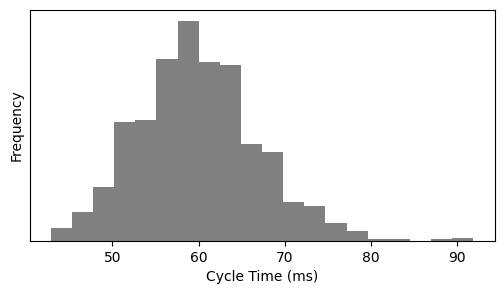

In [7]:
import mistat
defaults = {'m': 60, 'p0': 110_000, 't': 296, 's': 0.0125, 'v0': 0.0075, 'k': 3000, 't0': 350}
simulator = mistat.PistonSimulator(**defaults, n_simulation=1000, seed=123)
result = simulator.simulate()

result['seconds'] = 1000 * result['seconds']
result = result.rename({'seconds': 'milliseconds'}, axis=1)

fig, ax = plt.subplots(figsize=(6, 3))
ax = result['milliseconds'].plot.hist(bins=20, ax=ax, color='grey')
ax.set_xlabel('Cycle Time (ms)')
ax.set_yticks([])
plt.savefig(common.FIGURES_DIR / 'cycle-times.png', format='png', bbox_inches='tight', dpi=300)
plt.show()


In [6]:
result['milliseconds'].mean(), result['milliseconds'].std(), len(result['milliseconds'])


(np.float64(59.91155379164292), np.float64(7.0107414183359875), 1000)

# Prepare dataset

In [5]:
# s, v0, k, t0 are mapped to x1, x2, x3, x4
n_replicate = 2
n_bootstrap = 1000
approach = 'single' # 
approach = 'individual'

full_data = common.preparePistonDataset(include_t0=False, n_replicate=n_replicate, seed=2)
full_data

,milliseconds,group,x1,x2,x3
0,45.313927,1,-1.000000,-1.000000,-1.000000
1,58.337529,1,-1.000000,-1.000000,-1.000000
2,37.573244,2,1.000000,-1.000000,-1.000000
3,39.556541,2,1.000000,-1.000000,-1.000000
4,91.348734,3,-1.000000,1.000000,-1.000000
5,90.814295,3,-1.000000,1.000000,-1.000000
6,46.289716,4,1.000000,1.000000,-1.000000
7,60.424883,4,1.000000,1.000000,-1.000000
8,70.489900,5,-1.000000,-1.000000,1.000000
9,64.258239,5,-1.000000,-1.000000,1.000000


# Build a variety of models using main effects and interactions

In [6]:
main_terms_significant = 'x1 + x2 + x3'
interaction_terms = 'x1:x2 + x1:x3 + x2:x3'
quadratic_terms = 'I(x1**2) + I(x2**2) + I(x3**2)'
formula_full = f'milliseconds ~ {main_terms_significant} + {interaction_terms} + {quadratic_terms}'
group = ['x1', 'x2', 'x3']

In [7]:
import statsmodels.formula.api as smf
model = smf.ols(formula_full, data=full_data).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           milliseconds   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     17.55
Date:                Tue, 18 Feb 2025   Prob (F-statistic):           2.36e-10
Time:                        09:55:11   Log-Likelihood:                -152.59
No. Observations:                  44   AIC:                             325.2
Df Residuals:                      34   BIC:                             343.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     61.2873      2.206     27.787      0.000      56.805      65.770
x1           -13.6560      1.689     -8.084      0.000     -17.089     -10.223
x2            14.7374      1.689      8.724      0.000      11.304      18.170
x3             5.2223      1.689      3.091      0.004       1.789       8.655
x1:x2         -4.5067      2.207     -2.042      0.049      -8.992      -0.021
x1:x3         -2.4993      2.207     -1.132      0.265      -6.985       1.986
x2:x3          1.7359      2.207      0.786      0.437      -2.750       6.221
I(x1 ** 2)     0.7141      1.586      0.450      0.655      -2.509       3.937
I(x2 ** 2)     0.0501      1.586      0.032      0.975      -3.173       3.273
I(x3 ** 2)     1.2776      1.586      0.806      0.426      -1.946       4.501
==============================================================================
Omnibus:                        1.739   Durbin-Watson:                   2.562
Prob(Omnibus):                  0.419   Jarque-Bera (JB):                1.001
Skew:                          -0.346   Prob(JB):                        0.606
Kurtosis:                       3.257   Cond. No.                         3.15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

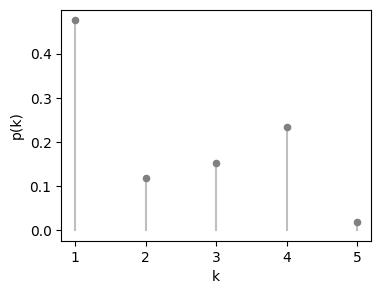

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
n_replicate = 5
x = pd.Series(np.array([np.floor(max(1, np.random.uniform(f, n_replicate + 0.05))) for f in np.linspace(-10, n_replicate, 100_000)]))
p = pd.DataFrame(sorted(x.value_counts().items()), columns=['k', 'p(k)'])
p['p(k)'] = p['p(k)'] / p['p(k)'].sum()
p['k'] = p['k'].astype(int)
fig, ax = plt.subplots(figsize=(4, 3))
p.plot.scatter(x='k', y='p(k)', color='grey', ax=ax)
for _, row in p.iterrows():
    k = row['k']
    p_k = row['p(k)']
    ax.plot((k, k), (0, p_k), color='grey', alpha=0.5)

plt.savefig(common.FIGURES_DIR / 'sample_probability.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

